# 🎯 Análise de Centralidade - Game of Thrones
## Quem é matematicamente o personagem mais importante?

Este notebook aplica algoritmos de teoria dos grafos para responder:
1. **Quem é o personagem mais importante?**
2. **Como os grupos de poder se organizam?**

In [5]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

# Configurações de visualização
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 1️⃣ Construir o Grafo de Interações

In [6]:
# Carregar dataset
df = pd.read_csv("../datasets/interacoes.csv")

# Verificar colunas disponíveis
print("Colunas disponíveis:", df.columns.tolist())
print("\nPrimeiras linhas:")
print(df.head())

# Filtrar apenas interações diretas (1-para-1)
df_direct = df[df['num_personagens_cena'] == 2].copy()

# Agrupar e contar
df_grouped = df_direct.groupby(['falante', 'ouvinte']).size().reset_index(name='weight')

# Criar grafo
G = nx.from_pandas_edgelist(df_grouped, 'falante', 'ouvinte', 
                             edge_attr='weight', create_using=nx.Graph())

print(f"\n✅ Grafo criado:")
print(f"   Personagens (nós): {G.number_of_nodes()}")
print(f"   Conexões (arestas): {G.number_of_edges()}")

Colunas disponíveis: ['NTemporada', 'NEpisodio', 'NCena', 'falante', 'ouvinte', 'fala', 'tamanho_fala', 'descricao_cena', 'num_personagens_cena', 'tipo_interacao']

Primeiras linhas:
   NTemporada  NEpisodio  NCena       falante ouvinte  \
0           1          1      0  WAYMAR ROYCE    WILL   
1           1          1      0  WAYMAR ROYCE   Royce   
2           1          1      0  WAYMAR ROYCE   Gared   
3           1          1      0          WILL   Royce   
4           1          1      0          WILL   Gared   

                                                fala  tamanho_fala  \
0  What d’you expect? They’re savages. One lot st...           136   
1  What d’you expect? They’re savages. One lot st...           136   
2  What d’you expect? They’re savages. One lot st...           136   
3  I’ve never seen wildlings do a thing like this...           103   
4  I’ve never seen wildlings do a thing like this...           103   

                                      descricao_cena 

## 2️⃣ Centralidade de Grau
**Quem tem mais conexões diretas?**

In [7]:
degree_cent = nx.degree_centrality(G)
top_degree = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:15]

df_degree = pd.DataFrame(top_degree, columns=['Personagem', 'Centralidade de Grau'])
df_degree['Num Conexões'] = [G.degree(p) for p, _ in top_degree]
df_degree

,Personagem,Centralidade de Grau,Num Conexões
0,Jon Snow,0.187500,42
1,TYRION,0.187500,42
2,Jaime Lannister,0.160714,36
3,CERSEI,0.151786,34
4,DAENERYS TARGARYEN,0.147321,33
5,Sansa Stark,0.138393,31
6,Samwell Tarly,0.111607,25
7,BRAN STARK,0.107143,24
8,DAVOS,0.102679,23
9,ARYA STARK,0.102679,23


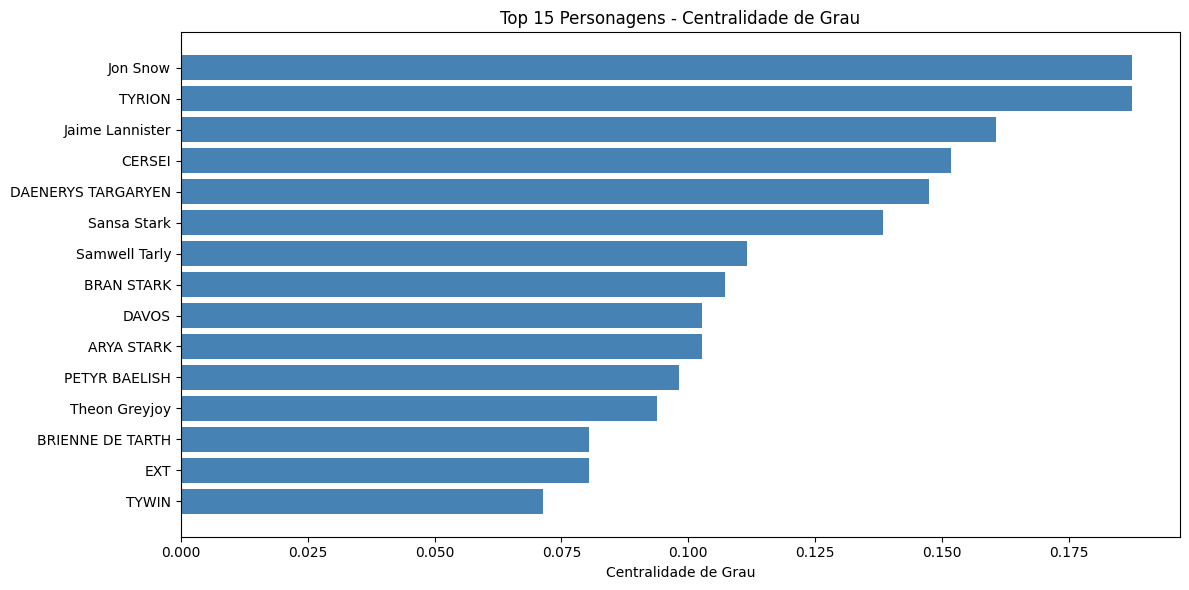

In [8]:
# Visualizar
plt.figure(figsize=(12, 6))
plt.barh(df_degree['Personagem'], df_degree['Centralidade de Grau'], color='steelblue')
plt.xlabel('Centralidade de Grau')
plt.title('Top 15 Personagens - Centralidade de Grau')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 3️⃣ Centralidade de Intermediação (Betweenness)
**Quem conecta diferentes grupos?**

In [9]:
betweenness_cent = nx.betweenness_centrality(G, weight='weight')
top_betweenness = sorted(betweenness_cent.items(), key=lambda x: x[1], reverse=True)[:15]

df_betweenness = pd.DataFrame(top_betweenness, columns=['Personagem', 'Betweenness'])
df_betweenness

,Personagem,Betweenness
0,EXT,0.510995
1,DAENERYS TARGARYEN,0.178398
2,PETYR BAELISH,0.176458
3,DAVOS,0.176440
4,Jaime Lannister,0.134477
5,Jon Snow,0.134114
6,ARYA STARK,0.112980
7,Samwell Tarly,0.110205
8,CERSEI,0.098733
9,TYRION,0.087791


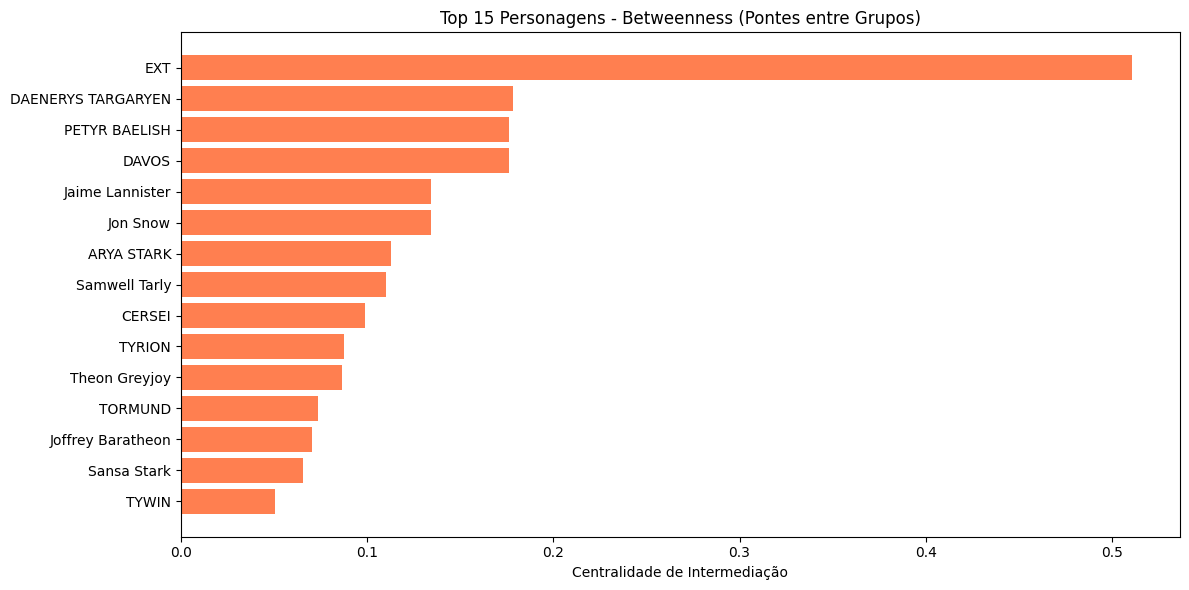

In [10]:
# Visualizar
plt.figure(figsize=(12, 6))
plt.barh(df_betweenness['Personagem'], df_betweenness['Betweenness'], color='coral')
plt.xlabel('Centralidade de Intermediação')
plt.title('Top 15 Personagens - Betweenness (Pontes entre Grupos)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4️⃣ PageRank
**Quem é mais influente?**

In [11]:
pagerank = nx.pagerank(G, weight='weight')
top_pagerank = sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:15]

df_pagerank = pd.DataFrame(top_pagerank, columns=['Personagem', 'PageRank'])
df_pagerank

,Personagem,PageRank
0,TYRION,0.064418
1,Jon Snow,0.049675
2,Jaime Lannister,0.041052
3,CERSEI,0.039560
4,DAENERYS TARGARYEN,0.039143
5,Sansa Stark,0.036707
6,ARYA STARK,0.033252
7,Samwell Tarly,0.025336
8,Theon Greyjoy,0.023548
9,DAVOS,0.019353


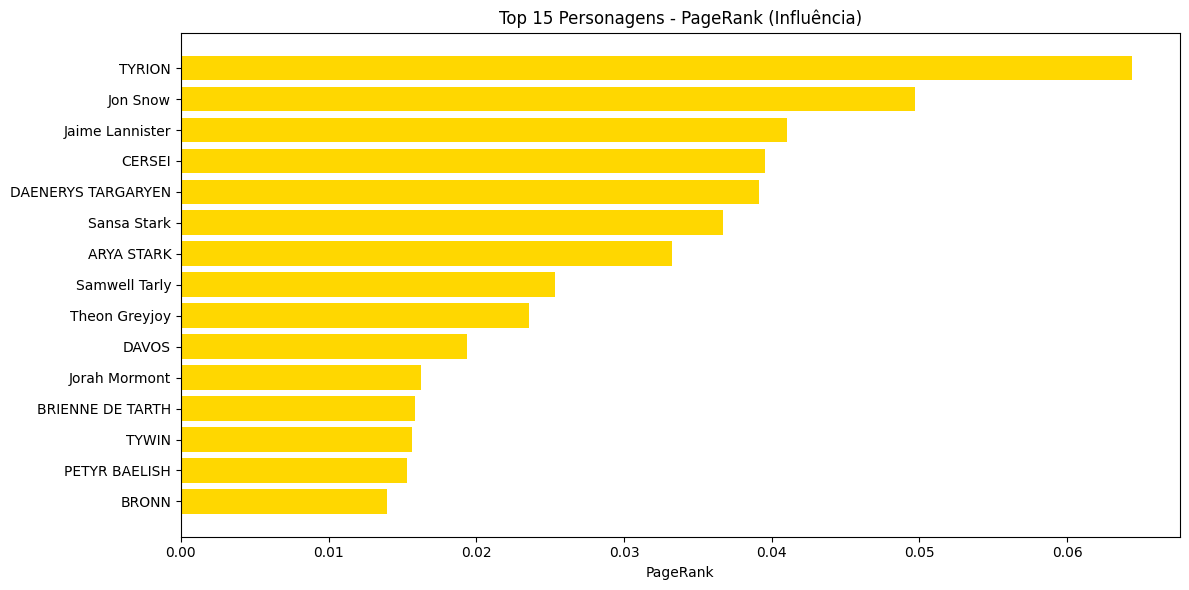

In [12]:
# Visualizar
plt.figure(figsize=(12, 6))
plt.barh(df_pagerank['Personagem'], df_pagerank['PageRank'], color='gold')
plt.xlabel('PageRank')
plt.title('Top 15 Personagens - PageRank (Influência)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5️⃣ Centralidade de Proximidade (Closeness)
**Quem está mais próximo de todos?**

In [13]:
closeness_cent = nx.closeness_centrality(G, distance='weight')
top_closeness = sorted(closeness_cent.items(), key=lambda x: x[1], reverse=True)[:15]

df_closeness = pd.DataFrame(top_closeness, columns=['Personagem', 'Closeness'])
df_closeness

,Personagem,Closeness
0,EXT,0.202349
1,DAENERYS TARGARYEN,0.185892
2,Joffrey Baratheon,0.183908
3,PETYR BAELISH,0.182559
4,Sansa Stark,0.181966
5,DAVOS,0.181671
6,TYRION,0.178202
7,Samwell Tarly,0.176656
8,Jaime Lannister,0.175824
9,TORMUND,0.174727


## 6️⃣ Detecção de Comunidades
**Como os grupos de poder se organizam?**

In [14]:
# Instalar se necessário
# !pip install python-louvain

import community as community_louvain

communities = community_louvain.best_partition(G, weight='weight')
community_counts = Counter(communities.values())

print(f"Total de comunidades: {len(community_counts)}\n")

# Mostrar maiores comunidades
for comm_id, count in community_counts.most_common(5):
    membros = [p for p, c in communities.items() if c == comm_id]
    print(f"Comunidade {comm_id + 1} ({count} membros):")
    print(f"  {', '.join(membros[:15])}")
    print()

ModuleNotFoundError: No module named 'community'

## 7️⃣ RANKING CONSOLIDADO
**Resposta final: Quem é o personagem mais importante?**

In [ ]:
# Consolidar todas as métricas
personagens = list(G.nodes())

df_final = pd.DataFrame({
    'Personagem': personagens,
    'Grau': [degree_cent[p] for p in personagens],
    'Betweenness': [betweenness_cent[p] for p in personagens],
    'PageRank': [pagerank[p] for p in personagens],
    'Closeness': [closeness_cent[p] for p in personagens]
})

# Normalizar e calcular score médio
df_final['Score_Total'] = (
    df_final['Grau'] + 
    df_final['Betweenness'] + 
    df_final['PageRank'] * 100 + 
    df_final['Closeness']
) / 4

df_final = df_final.sort_values('Score_Total', ascending=False).reset_index(drop=True)
df_final.head(20)

,Personagem,Grau,Betweenness,PageRank,Closeness,Score_Total
0,TYRION LANNISTER,0.184932,0.147401,0.058669,0.175395,1.593652
1,JON SNOW,0.157534,0.120873,0.045422,0.173783,1.248605
2,JAIME LANNISTER,0.126712,0.048971,0.036815,0.145584,1.000690
3,CERSEI LANNISTER,0.130137,0.142342,0.034125,0.179926,0.966226
4,DAENERYS TARGARYEN,0.126712,0.132451,0.033707,0.174931,0.951188
5,ARYA STARK,0.102740,0.101486,0.033814,0.145424,0.932769
6,SANSA STARK,0.106164,0.111393,0.031669,0.176919,0.890334
7,THEON GREYJOY,0.092466,0.093500,0.022674,0.167196,0.655135
8,SAMWELL TARLY,0.082192,0.083507,0.022119,0.160310,0.634479
9,DAVOS SEAWORTH,0.082192,0.150912,0.017790,0.170646,0.545697


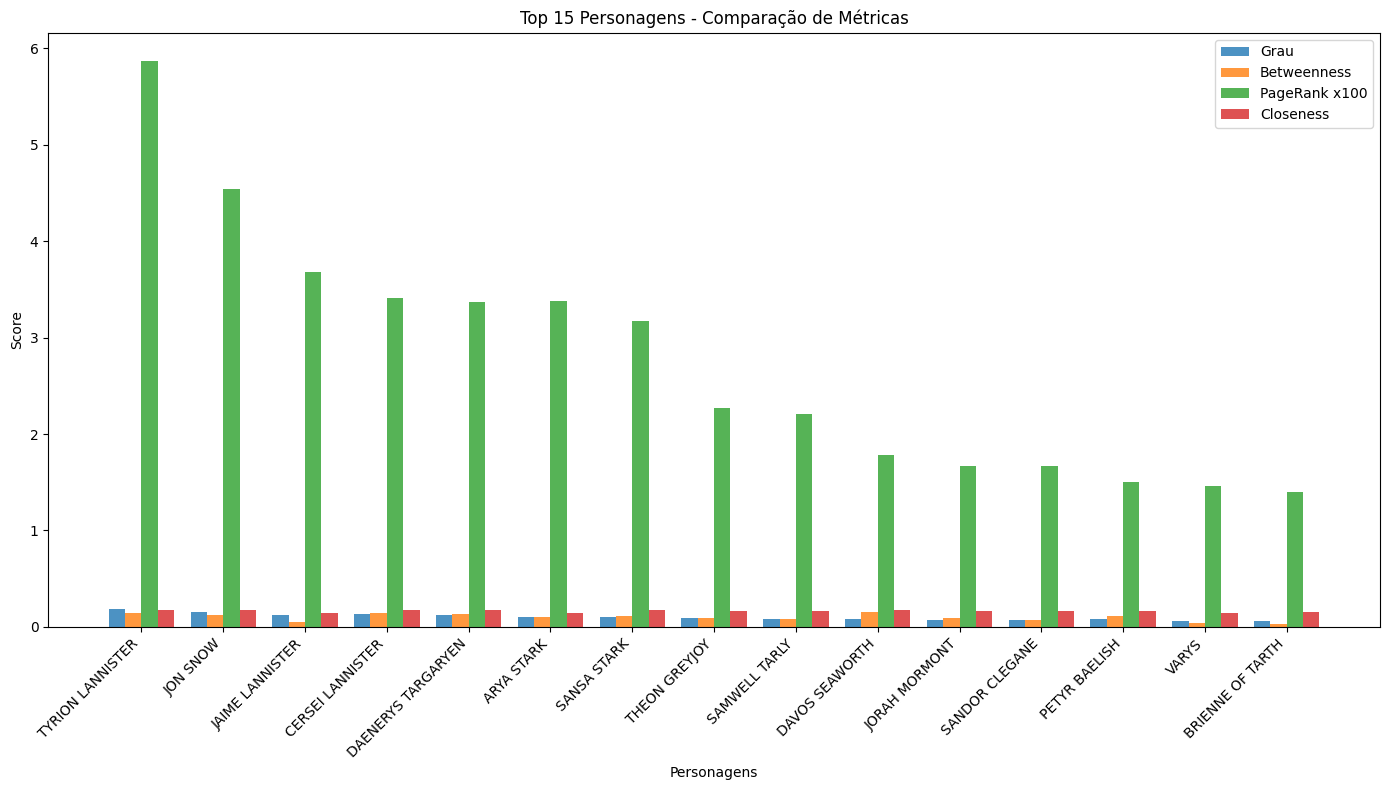

In [ ]:
# Visualizar Top 15
top15 = df_final.head(15)

fig, ax = plt.subplots(figsize=(14, 8))

x = range(len(top15))
width = 0.2

ax.bar([i - 1.5*width for i in x], top15['Grau'], width, label='Grau', alpha=0.8)
ax.bar([i - 0.5*width for i in x], top15['Betweenness'], width, label='Betweenness', alpha=0.8)
ax.bar([i + 0.5*width for i in x], top15['PageRank']*100, width, label='PageRank x100', alpha=0.8)
ax.bar([i + 1.5*width for i in x], top15['Closeness'], width, label='Closeness', alpha=0.8)

ax.set_xlabel('Personagens')
ax.set_ylabel('Score')
ax.set_title('Top 15 Personagens - Comparação de Métricas')
ax.set_xticks(x)
ax.set_xticklabels(top15['Personagem'], rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

## 8️⃣ Visualização do Grafo

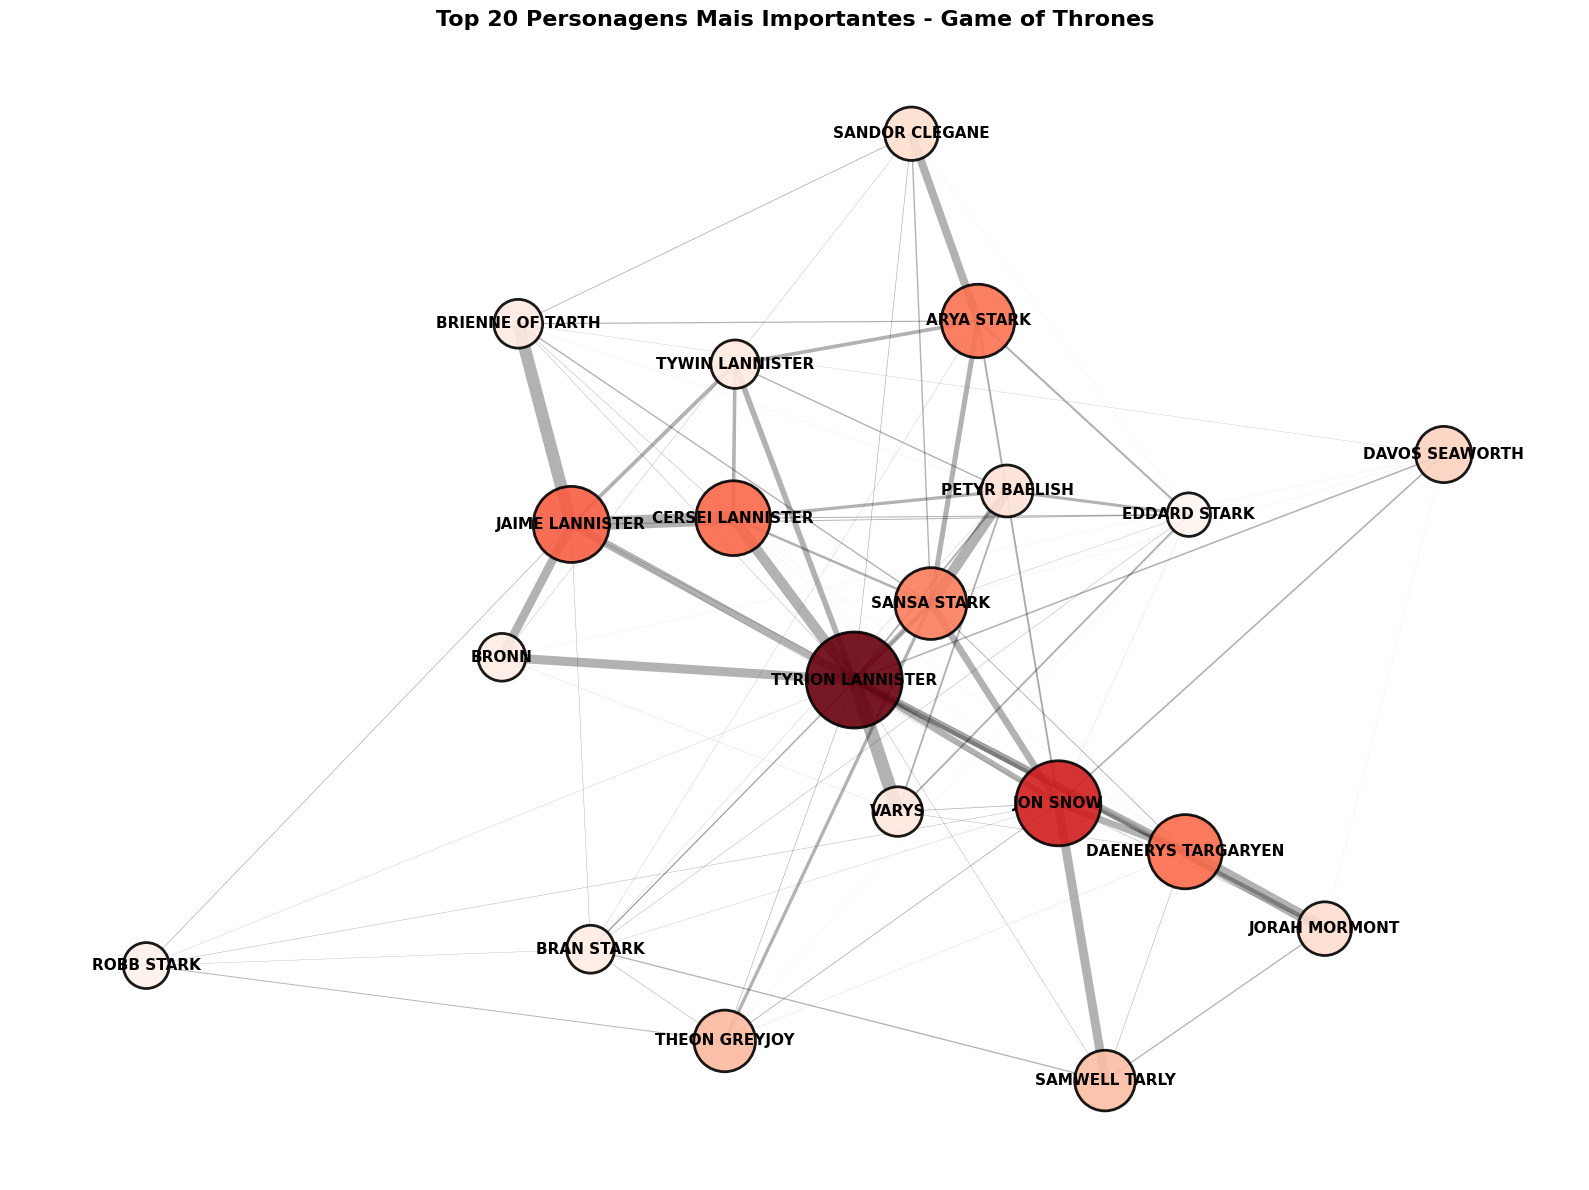

In [ ]:
# Subgrafo dos top 20
top_20 = df_final.head(20)['Personagem'].tolist()
G_top = G.subgraph(top_20).copy()

plt.figure(figsize=(16, 12))

pos = nx.spring_layout(G_top, k=2, iterations=50, seed=42)

# Tamanho e cor baseados no score
scores_dict = dict(zip(df_final['Personagem'], df_final['Score_Total']))
node_sizes = [scores_dict[n] * 3000 for n in G_top.nodes()]
node_colors = [scores_dict[n] for n in G_top.nodes()]

nx.draw_networkx_nodes(G_top, pos, node_size=node_sizes, node_color=node_colors,
                       cmap=plt.cm.Reds, alpha=0.9, edgecolors='black', linewidths=2)

widths = [G_top[u][v]['weight'] / 15 for u, v in G_top.edges()]
nx.draw_networkx_edges(G_top, pos, width=widths, alpha=0.3)

nx.draw_networkx_labels(G_top, pos, font_size=11, font_weight='bold')

plt.title('Top 20 Personagens Mais Importantes - Game of Thrones', 
          fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()